<a href="https://colab.research.google.com/github/rbuzmaa/MLproject/blob/main/Copy_of_resnet18_vs_efficientnetb0_MobileNetV2_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔬 Colon Cancer Detection — ResNet-18 vs EfficientNet-B0 vs MobileNetV2
**Dataset:** LC25000 (colon classes only)  
**Methodology:** Duplicate removal before splitting → strict train/val/test independence  
**Goal:** Fair comparison of both architectures under identical conditions

---
### 📋 Notebook Structure
| Cells | Purpose |
|---|---|
| 1–3 | Setup, GPU check, dataset download |
| 4–6 | Deduplication → clean split → audit |
| 7 | Shared transforms & dataloaders |
| 8–12 | **ResNet-18** — build, train, evaluate |
| 13–17 | **EfficientNet-B0** — build, train, evaluate |
| 18–19 | **Head-to-head comparison** + save results |

---
### ✅ Before running:
1. **Runtime → Change runtime type → T4 GPU**
2. Upload `kaggle.json` when prompted in Cell 2


## Cell 1 — GPU Check

In [ ]:
import torch
print('GPU available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU :', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')
else:
    print('⚠️  No GPU — Runtime → Change runtime type → T4 GPU')

GPU available: True
GPU : Tesla T4
VRAM: 15.6 GB


## Cell 2 — Install & Kaggle Auth

In [ ]:
!pip install -q imagehash grad-cam

from google.colab import files
print('Upload kaggle.json...')
uploaded = files.upload()
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('✅ Kaggle ready')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 44.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 26.7 MB/s eta 0:00:00
Upload kaggle.json...


Saving kaggle.json to kaggle.json
✅ Kaggle ready


## Cell 3 — Download Dataset

In [ ]:
!kaggle datasets download -d andrewmvd/lung-and-colon-cancer-histopathological-images -p /content/
!unzip -q /content/lung-and-colon-cancer-histopathological-images.zip -d /content/lc25000

import os
base = '/content/lc25000/lung_colon_image_set/colon_image_sets'
print('Colon classes:')
for cls in sorted(os.listdir(base)):
    if 'colon' in cls:
        print(f'  {cls}: {len(os.listdir(os.path.join(base, cls)))} images')

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images
License(s): CC-BY-SA-4.0
 99% 1.75G/1.76G [00:07<00:00, 246MB/s]
100% 1.76G/1.76G [00:07<00:00, 244MB/s]
Colon classes:
  colon_aca: 5000 images
  colon_n: 5000 images


## Cell 4 — Configuration


In [ ]:
class Config:
    RAW_DATA_DIR    = '/content/lc25000/lung_colon_image_set/colon_image_sets'
    DEDUP_DIR       = '/content/deduped'       # unique images only
    SPLIT_DATA_DIR  = '/content/data_split'    # train/val/test

    CLASSES      = ['colon_aca', 'colon_n']
    CLASS_NAMES  = ['Adenocarcinoma (Malignant)', 'Normal (Benign)']

    PHASH_THRESHOLD = 6     # pHash distance ≤ 6 → considered duplicate
                            # 0=identical, 6=very similar, 10=loosely similar

    TRAIN_RATIO  = 0.70
    VAL_RATIO    = 0.15
    TEST_RATIO   = 0.15
    RANDOM_SEED  = 42

    IMAGE_SIZE   = 224
    NUM_WORKERS  = 2
    NUM_CLASSES  = 2

    # ── ResNet-18 hyperparameters ─────────────────────────────────────
    RN_BATCH_SIZE   = 64
    RN_PHASE1_EPOCHS = 8
    RN_PHASE1_LR     = 1e-3
    RN_PHASE2_EPOCHS = 15
    RN_PHASE2_LR     = 3e-5

    # ── EfficientNet-B0 hyperparameters ──────────────────────────────
    # B0 is lighter than B3 — safe to use batch 64 on T4
    EN_BATCH_SIZE    = 64
    EN_PHASE1_EPOCHS = 8
    EN_PHASE1_LR     = 1e-3
    EN_PHASE2_EPOCHS = 15
    EN_PHASE2_LR     = 1e-5   # B0 deeper than ResNet-18 → more conservative LR

    EARLY_STOP_PATIENCE = 5
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

cfg = Config()
print(f'Device : {cfg.DEVICE}')
print(f'pHash threshold : {cfg.PHASH_THRESHOLD}')

Device : cuda
pHash threshold : 6


## Cell 5 — Deduplication + Split
> Implements: *'Duplicate images were removed before dataset splitting to ensure independence between training and testing sets.'*
>
> **How it works:** Each image is hashed with perceptual hash (pHash). Images with hash distance ≤ threshold are near-duplicates (same source patch, different augmentation). Only ONE representative per duplicate group is kept. The deduplicated set is then split into train/val/test.

In [ ]:
import shutil, random, hashlib
from pathlib import Path
from PIL import Image
import imagehash
import numpy as np
from collections import defaultdict

# ── Step 1: Find duplicate groups via pHash ───────────────────────────────
def find_duplicate_groups(class_dir, threshold):
    """
    Returns list of groups. Each group = list of near-duplicate file paths.
    Only the FIRST file in each group will be kept (removal approach).
    """
    files = (list(Path(class_dir).glob('*.jpeg')) +
             list(Path(class_dir).glob('*.jpg'))  +
             list(Path(class_dir).glob('*.png')))

    print(f'  Computing pHash for {len(files)} images...', end='', flush=True)
    hashes = {}
    for f in files:
        try:
            hashes[f] = imagehash.phash(Image.open(f).convert('RGB'), hash_size=8)
        except Exception:
            pass
    print(' done.')

    # Union-Find grouping
    parent = {f: f for f in hashes}
    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x
    def union(x, y):
        parent[find(x)] = find(y)

    flist = list(hashes.keys())
    for i in range(len(flist)):
        for j in range(i + 1, len(flist)):
            if hashes[flist[i]] - hashes[flist[j]] <= threshold:
                union(flist[i], flist[j])

    groups = defaultdict(list)
    for f in flist:
        groups[find(f)].append(f)
    return list(groups.values())


# ── Step 2: Remove duplicates — keep one per group ────────────────────────
def deduplicate_dataset(cfg):
    """
    Copies ONE representative image per duplicate group into DEDUP_DIR.
    This is the removal step — duplicates are excluded, not just grouped.
    """
    if Path(cfg.DEDUP_DIR).exists():
        print('Dedup directory exists — skipping.')
        return

    print('\n── Step 1: Removing duplicates ─────────────────────────────')
    for cls in cfg.CLASSES:
        Path(f'{cfg.DEDUP_DIR}/{cls}').mkdir(parents=True, exist_ok=True)
        src    = Path(cfg.RAW_DATA_DIR) / cls
        groups = find_duplicate_groups(src, cfg.PHASH_THRESHOLD)

        kept, removed = 0, 0
        for group in groups:
            # Sort for reproducibility — always keep the same representative
            group.sort(key=lambda f: f.name)
            representative = group[0]          # keep first
            shutil.copy(representative, Path(cfg.DEDUP_DIR) / cls / representative.name)
            kept    += 1
            removed += len(group) - 1

        total = kept + removed
        print(f'  {cls}: {total} → kept {kept} unique | removed {removed} duplicates '
              f'({removed/total*100:.1f}% removed)')


# ── Step 3: Split the deduplicated dataset ────────────────────────────────
def split_deduped(cfg):
    """
    Standard random split on the already-deduplicated images.
    No duplicate can span splits because duplicates were already removed.
    """
    if Path(cfg.SPLIT_DATA_DIR).exists():
        print('Split directory exists — skipping.')
        return

    print('\n── Step 2: Splitting deduplicated dataset ──────────────────')
    for split in ['train', 'val', 'test']:
        for cls in cfg.CLASSES:
            Path(f'{cfg.SPLIT_DATA_DIR}/{split}/{cls}').mkdir(parents=True, exist_ok=True)

    for cls in cfg.CLASSES:
        files = (list((Path(cfg.DEDUP_DIR) / cls).glob('*.jpeg')) +
                 list((Path(cfg.DEDUP_DIR) / cls).glob('*.jpg'))  +
                 list((Path(cfg.DEDUP_DIR) / cls).glob('*.png')))
        random.seed(cfg.RANDOM_SEED)
        random.shuffle(files)

        n       = len(files)
        n_train = int(n * cfg.TRAIN_RATIO)
        n_val   = int(n * cfg.VAL_RATIO)

        for split, flist in zip(
            ['train', 'val', 'test'],
            [files[:n_train], files[n_train:n_train+n_val], files[n_train+n_val:]]
        ):
            for f in flist:
                shutil.copy(f, Path(cfg.SPLIT_DATA_DIR) / split / cls / f.name)

        print(f'  {cls}: {n_train} train | {n_val} val | {n-n_train-n_val} test  '
              f'(from {n} unique images)')

# Run both steps
deduplicate_dataset(cfg)
split_deduped(cfg)


── Step 1: Removing duplicates ─────────────────────────────
  Computing pHash for 5000 images... done.
  colon_aca: 5000 → kept 4171 unique | removed 829 duplicates (16.6% removed)
  Computing pHash for 5000 images... done.
  colon_n: 5000 → kept 4231 unique | removed 769 duplicates (15.4% removed)

── Step 2: Splitting deduplicated dataset ──────────────────
  colon_aca: 2919 train | 625 val | 627 test  (from 4171 unique images)
  colon_n: 2961 train | 634 val | 636 test  (from 4231 unique images)


## Cell 6 — Split Audit (Verify No Leakage)

In [ ]:
import pandas as pd

# ── Count images per split ────────────────────────────────────────────────
print('── Dataset Summary ─────────────────────────────────────────')
counts = {}
for split in ['train', 'val', 'test']:
    counts[split] = {}
    for cls in cfg.CLASSES:
        p = Path(cfg.SPLIT_DATA_DIR) / split / cls
        counts[split][cls] = len(list(p.iterdir()))
print(pd.DataFrame(counts).T.to_string())

# ── MD5 cross-split exact duplicate audit ────────────────────────────────
print('\n── Exact Duplicate Audit (MD5) ─────────────────────────────')
all_md5 = defaultdict(list)
for split in ['train', 'val', 'test']:
    for cls in cfg.CLASSES:
        for f in (Path(cfg.SPLIT_DATA_DIR) / split / cls).iterdir():
            h = hashlib.md5(f.read_bytes()).hexdigest()
            all_md5[h].append((split, f.name))

cross_split_leaks = 0
for h, locs in all_md5.items():
    splits_seen = set(s for s, _ in locs)
    if len(splits_seen) > 1:
        cross_split_leaks += 1

if cross_split_leaks == 0:
    print('  ✅ Zero exact duplicates across splits — dataset is clean.')
else:
    print(f'  ⚠️  {cross_split_leaks} exact duplicate(s) found across splits!')

# ── pHash cross-split near-duplicate audit ────────────────────────────────
print('\n── Near-Duplicate Audit (pHash) ────────────────────────────')
split_ph = {s: {} for s in ['train', 'val', 'test']}
for split in ['train', 'val', 'test']:
    for cls in cfg.CLASSES:
        for f in (Path(cfg.SPLIT_DATA_DIR) / split / cls).iterdir():
            try:
                split_ph[split][f] = imagehash.phash(Image.open(f).convert('RGB'))
            except Exception:
                pass

boundaries = [('train','val'), ('train','test'), ('val','test')]
total_near_dupes = 0
for s1, s2 in boundaries:
    leaks = sum(
        1 for f1, h1 in split_ph[s1].items()
          for f2, h2 in split_ph[s2].items()
          if (h1 - h2) <= cfg.PHASH_THRESHOLD
    )
    status = '✅ CLEAN' if leaks == 0 else f'⚠️  {leaks} near-duplicates'
    print(f'  {s1:5s} ↔ {s2:5s}: {status}')
    total_near_dupes += leaks

print(f'\n  Total near-duplicates across boundaries: {total_near_dupes}')
if total_near_dupes == 0:
    print('  ✅ Split is leakage-free. Results will be reliable.')
print('─' * 55)

── Dataset Summary ─────────────────────────────────────────
       colon_aca  colon_n
train       2919     2961
val          625      634
test         627      636

── Exact Duplicate Audit (MD5) ─────────────────────────────
  ✅ Zero exact duplicates across splits — dataset is clean.

── Near-Duplicate Audit (pHash) ────────────────────────────
  train ↔ val  : ✅ CLEAN
  train ↔ test : ✅ CLEAN
  val   ↔ test : ✅ CLEAN

  Total near-duplicates across boundaries: 0
  ✅ Split is leakage-free. Results will be reliable.
───────────────────────────────────────────────────────


## Cell 7 — Shared Transforms, DataLoaders & Utilities

In [ ]:
import copy, torch.nn as nn, torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, WeightedRandomSampler
from tqdm.notebook import tqdm
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# ── Transforms — minimal augmentation (LC25000 pre-augmented) ─────────────
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((cfg.IMAGE_SIZE, cfg.IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize(MEAN, STD),
    ]),
    'val': transforms.Compose([
        transforms.Resize((cfg.IMAGE_SIZE, cfg.IMAGE_SIZE)),
        transforms.ToTensor(), transforms.Normalize(MEAN, STD),
    ]),
    'test': transforms.Compose([
        transforms.Resize((cfg.IMAGE_SIZE, cfg.IMAGE_SIZE)),
        transforms.ToTensor(), transforms.Normalize(MEAN, STD),
    ]),
}

def make_dataloaders(batch_size):
    ds = {
        s: datasets.ImageFolder(f'{cfg.SPLIT_DATA_DIR}/{s}', transform=data_transforms[s])
        for s in ['train', 'val', 'test']
    }
    counts_arr   = np.bincount([l for _, l in ds['train'].samples])
    sample_wts   = [1.0 / counts_arr[l] for _, l in ds['train'].samples]
    sampler      = WeightedRandomSampler(sample_wts, len(sample_wts))
    dl = {
        'train': DataLoader(ds['train'], batch_size=batch_size, sampler=sampler,
                            num_workers=cfg.NUM_WORKERS, pin_memory=True),
        'val'  : DataLoader(ds['val'],   batch_size=batch_size, shuffle=False,
                            num_workers=cfg.NUM_WORKERS, pin_memory=True),
        'test' : DataLoader(ds['test'],  batch_size=batch_size, shuffle=False,
                            num_workers=cfg.NUM_WORKERS, pin_memory=True),
    }
    return ds, dl

# ── Shared training loop ──────────────────────────────────────────────────
def train_model(model, criterion, optimizer, scheduler,
                dataloaders, num_epochs, save_path, phase_name):
    history          = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    best_val_loss    = float('inf')
    best_weights     = copy.deepcopy(model.state_dict())
    patience_counter = 0

    for epoch in range(1, num_epochs + 1):
        print(f'[{phase_name}] Epoch {epoch}/{num_epochs}')
        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()
            running_loss, running_correct = 0.0, 0

            for imgs, labels in tqdm(dataloaders[phase], desc=f'  {phase}', leave=False):
                imgs, labels = imgs.to(cfg.DEVICE), labels.to(cfg.DEVICE)
                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    out   = model(imgs)
                    loss  = criterion(out, labels)
                    preds = out.argmax(dim=1)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                running_loss    += loss.item() * imgs.size(0)
                running_correct += (preds == labels).sum().item()

            e_loss = running_loss / len(dataloaders[phase].dataset)
            e_acc  = running_correct / len(dataloaders[phase].dataset)
            history[f'{phase}_loss'].append(e_loss)
            history[f'{phase}_acc'].append(e_acc)
            print(f'    {phase:5s} → loss: {e_loss:.4f}  acc: {e_acc:.4f}')

            if phase == 'val':
                scheduler.step(e_loss)
                if e_loss < best_val_loss:
                    best_val_loss    = e_loss
                    best_weights     = copy.deepcopy(model.state_dict())
                    patience_counter = 0
                    torch.save(best_weights, save_path)
                    print(f'    ✅ Best saved (val_loss={best_val_loss:.4f})')
                else:
                    patience_counter += 1
                    print(f'    ⏳ No improvement ({patience_counter}/{cfg.EARLY_STOP_PATIENCE})')
                    if patience_counter >= cfg.EARLY_STOP_PATIENCE:
                        print(f'    🛑 Early stopping at epoch {epoch}')
                        model.load_state_dict(best_weights)
                        return model, history

    model.load_state_dict(best_weights)
    return model, history

# ── Shared evaluation function ────────────────────────────────────────────
def evaluate_model(model, loader, dataset):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc='Evaluating'):
            imgs  = imgs.to(cfg.DEVICE)
            probs = torch.softmax(model(imgs), dim=1)
            all_preds.extend(probs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    preds  = np.array(all_preds)
    labels = np.array(all_labels)
    probs  = np.array(all_probs)

    mal_idx  = dataset.class_to_idx['colon_aca']
    binary   = (labels == mal_idx).astype(int)
    mal_prob = probs[:, mal_idx]
    auc      = roc_auc_score(binary, mal_prob)
    if auc < 0.5: auc = 1 - auc

    cm             = confusion_matrix(labels, preds)
    tn, fp, fn, tp = cm.ravel()
    sensitivity    = tp / (tp + fn)
    specificity    = tn / (tn + fp)
    ppv            = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv            = tn / (tn + fn) if (tn + fn) > 0 else 0
    accuracy       = (tp + tn) / len(labels)

    return {
        'preds': preds, 'labels': labels, 'probs': probs,
        'auc': auc, 'binary': binary, 'mal_prob': mal_prob,
        'sensitivity': sensitivity, 'specificity': specificity,
        'ppv': ppv, 'npv': npv, 'accuracy': accuracy, 'cm': cm
    }

# ── Shared criterion (same for both models) ───────────────────────────────
def make_criterion(dataset):
    counts_arr   = np.bincount([l for _, l in dataset.samples])
    class_weights = torch.tensor(
        counts_arr.sum() / (len(counts_arr) * counts_arr), dtype=torch.float
    ).to(cfg.DEVICE)
    return nn.CrossEntropyLoss(weight=class_weights)

print('✅ Shared utilities ready.')

✅ Shared utilities ready.


---
# 🔷 MODEL A — ResNet-18

## Cell 8 — Build ResNet-18

In [ ]:
def build_resnet18(num_classes, freeze_backbone=True):
    """
    ResNet-18: replace model.fc (single Linear layer) with a
    regularised Sequential head. Dropout compensates for minimal augmentation.
    """
    model = models.resnet18(weights='IMAGENET1K_V1')
    in_features = model.fc.in_features  # 512
    model.fc = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.BatchNorm1d(256),
        nn.Dropout(p=0.4),
        nn.Linear(256, num_classes),
    )
    if freeze_backbone:
        for name, p in model.named_parameters():
            if 'fc' not in name:
                p.requires_grad = False
    return model

rn_ds, rn_dl   = make_dataloaders(cfg.RN_BATCH_SIZE)
rn_model       = build_resnet18(cfg.NUM_CLASSES, freeze_backbone=True).to(cfg.DEVICE)
rn_criterion   = make_criterion(rn_ds['train'])

trainable = sum(p.numel() for p in rn_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in rn_model.parameters())
print(f'ResNet-18  |  Trainable: {trainable:,} / {total:,} params')
print(f'Train set  : {len(rn_ds["train"])} images (post-dedup)')
print(f'Test set   : {len(rn_ds["test"])}  images (post-dedup)')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 197MB/s]


ResNet-18  |  Trainable: 132,354 / 11,308,866 params
Train set  : 5880 images (post-dedup)
Test set   : 1263  images (post-dedup)


## Cell 9 — ResNet-18 Phase 1: Train Head Only

In [ ]:
print('ResNet-18 — Phase 1: head only (backbone frozen)')
rn_opt_p1 = optim.AdamW(
    filter(lambda p: p.requires_grad, rn_model.parameters()),
    lr=cfg.RN_PHASE1_LR, weight_decay=1e-4
)
rn_sch_p1 = optim.lr_scheduler.ReduceLROnPlateau(
    rn_opt_p1, mode='min', factor=0.5, patience=2
)
rn_model, rn_hist_p1 = train_model(
    rn_model, rn_criterion, rn_opt_p1, rn_sch_p1,
    rn_dl, cfg.RN_PHASE1_EPOCHS, '/content/rn_best.pth', 'RN Phase1'
)

ResNet-18 — Phase 1: head only (backbone frozen)
[RN Phase1] Epoch 1/8


  train:   0%|          | 0/92 [00:00<?, ?it/s]

    train → loss: 0.1480  acc: 0.9357


  val:   0%|          | 0/20 [00:00<?, ?it/s]

    val   → loss: 0.0412  acc: 0.9857
    ✅ Best saved (val_loss=0.0412)
[RN Phase1] Epoch 2/8


...

    val   → loss: 0.0367  acc: 0.9897
    ⏳ No improvement (4/5)
[RN Phase1] Epoch 7/8


  train:   0%|          | 0/92 [00:00<?, ?it/s]

    train → loss: 0.0870  acc: 0.9665


  val:   0%|          | 0/20 [00:00<?, ?it/s]

    val   → loss: 0.0337  acc: 0.9905
    ⏳ No improvement (5/5)
    🛑 Early stopping at epoch 7


## Cell 10 — ResNet-18 Phase 2: Full Fine-Tuning

In [ ]:
print('ResNet-18 — Phase 2: all layers unfrozen')
for p in rn_model.parameters():
    p.requires_grad = True

rn_opt_p2 = optim.AdamW(rn_model.parameters(), lr=cfg.RN_PHASE2_LR, weight_decay=1e-4)
rn_sch_p2 = optim.lr_scheduler.CosineAnnealingLR(
    rn_opt_p2, T_max=cfg.RN_PHASE2_EPOCHS, eta_min=1e-7
)
rn_model, rn_hist_p2 = train_model(
    rn_model, rn_criterion, rn_opt_p2, rn_sch_p2,
    rn_dl, cfg.RN_PHASE2_EPOCHS, '/content/rn_best.pth', 'RN Phase2'
)
rn_history = {k: rn_hist_p1[k] + rn_hist_p2[k] for k in rn_hist_p1}
print('\nResNet-18 training complete ✅')

ResNet-18 — Phase 2: all layers unfrozen
[RN Phase2] Epoch 1/15


  train:   0%|          | 0/92 [00:00<?, ?it/s]

    train → loss: 0.0337  acc: 0.9898


  val:   0%|          | 0/20 [00:00<?, ?it/s]

    val   → loss: 0.0018  acc: 1.0000
    ✅ Best saved (val_loss=0.0018)
[RN Phase2] Epoch 2/15


...

    val   → loss: 0.0001  acc: 1.0000
    ⏳ No improvement (2/5)
[RN Phase2] Epoch 15/15


  train:   0%|          | 0/92 [00:00<?, ?it/s]

    train → loss: 0.0017  acc: 0.9995


  val:   0%|          | 0/20 [00:00<?, ?it/s]

    val   → loss: 0.0000  acc: 1.0000
    ✅ Best saved (val_loss=0.0000)

ResNet-18 training complete ✅


## Cell 11 — ResNet-18 Training Curves

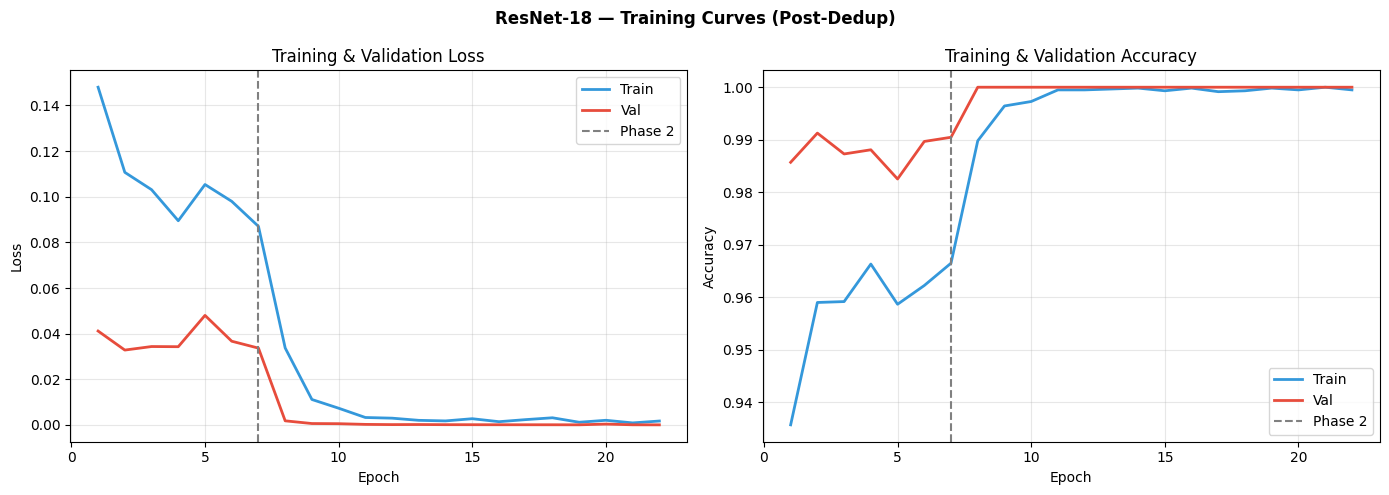

Train-val gap: -0.0005 ✅ Healthy


In [ ]:
p1_end_rn = len(rn_hist_p1['train_loss']) - 1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ResNet-18 — Training Curves (Post-Dedup)', fontweight='bold')
for ax, (tk, vk), title, ylabel_text in zip(axes,
    [('train_loss','val_loss'),('train_acc','val_acc')],
    ['Training & Validation Loss','Training & Validation Accuracy'],
    ['Loss', 'Accuracy']): # Added this list for y-axis labels
    epochs = range(1, len(rn_history[tk]) + 1)
    ax.plot(epochs, rn_history[tk], label='Train', lw=2, color='#3498DB')
    ax.plot(epochs, rn_history[vk], label='Val',   lw=2, color='#E74C3C')
    ax.axvline(p1_end_rn + 1, color='gray', ls='--', lw=1.5, label='Phase 2')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel_text); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

gap = rn_history['train_acc'][-1] - rn_history['val_acc'][-1]
print(f'Train-val gap: {gap:.4f}', '✅ Healthy' if abs(gap) < 0.05 else '⚠️  Check for overfit')

## Cell 12 — ResNet-18 Evaluation

In [ ]:
print('═'*55)
print('ResNet-18 — Test Set Evaluation')
print('═'*55)
rn_results = evaluate_model(rn_model, rn_dl['test'], rn_ds['test'])
print(classification_report(rn_results['labels'], rn_results['preds'],
                             target_names=cfg.CLASS_NAMES))
print(f'Sensitivity : {rn_results["sensitivity"]:.4f}')
print(f'Specificity : {rn_results["specificity"]:.4f}')
print(f'PPV         : {rn_results["ppv"]:.4f}')
print(f'NPV         : {rn_results["npv"]:.4f}')
print(f'AUC-ROC     : {rn_results["auc"]:.4f}')
print(f'Accuracy    : {rn_results["accuracy"]:.4f}')

═══════════════════════════════════════════════════════
ResNet-18 — Test Set Evaluation
═══════════════════════════════════════════════════════


Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

                            precision    recall  f1-score   support

Adenocarcinoma (Malignant)       1.00      1.00      1.00       627
           Normal (Benign)       1.00      1.00      1.00       636

                  accuracy                           1.00      1263
                 macro avg       1.00      1.00      1.00      1263
              weighted avg       1.00      1.00      1.00      1263

Sensitivity : 1.0000
Specificity : 1.0000
PPV         : 1.0000
NPV         : 1.0000
AUC-ROC     : 1.0000
Accuracy    : 1.0000


---
# 🔶 MODEL B — EfficientNet-B0
> **Why B0 and not B3?**  
> B0 is the base EfficientNet — fewer parameters (5.3M) vs B3 (12M), faster training, and more comparable to ResNet-18 in scale. Using B0 makes the comparison fairer: both models are lightweight baselines, and any performance difference reflects architecture rather than raw model size.

## Cell 13 — Build EfficientNet-B0

In [ ]:
def build_efficientnet_b0(num_classes, freeze_backbone=True):
    """
    EfficientNet-B0: replace model.classifier (Sequential block).
    model.classifier[1] is the final Linear layer — in_features = 1280.
    We replace the whole classifier block for consistent regularisation.
    """
    model = models.efficientnet_b0(weights='IMAGENET1K_V1')
    in_features = model.classifier[1].in_features  # 1280 for B0
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.BatchNorm1d(256),
        nn.Dropout(p=0.4),
        nn.Linear(256, num_classes),
    )
    if freeze_backbone:
        for name, p in model.named_parameters():
            if 'classifier' not in name:
                p.requires_grad = False
    return model

en_ds, en_dl   = make_dataloaders(cfg.EN_BATCH_SIZE)
en_model       = build_efficientnet_b0(cfg.NUM_CLASSES, freeze_backbone=True).to(cfg.DEVICE)
en_criterion   = make_criterion(en_ds['train'])

trainable = sum(p.numel() for p in en_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in en_model.parameters())
print(f'EfficientNet-B0  |  Trainable: {trainable:,} / {total:,} params')
print(f'Train set  : {len(en_ds["train"])} images (post-dedup)')
print(f'Test set   : {len(en_ds["test"])}  images (post-dedup)')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 181MB/s]

EfficientNet-B0  |  Trainable: 328,962 / 4,336,510 params
Train set  : 5880 images (post-dedup)
Test set   : 1263  images (post-dedup)


## Cell 14 — EfficientNet-B0 Phase 1: Train Head Only

In [ ]:
print('EfficientNet-B0 — Phase 1: head only (backbone frozen)')
en_opt_p1 = optim.AdamW(
    filter(lambda p: p.requires_grad, en_model.parameters()),
    lr=cfg.EN_PHASE1_LR, weight_decay=1e-4
)
en_sch_p1 = optim.lr_scheduler.ReduceLROnPlateau(
    en_opt_p1, mode='min', factor=0.5, patience=2
)
en_model, en_hist_p1 = train_model(
    en_model, en_criterion, en_opt_p1, en_sch_p1,
    en_dl, cfg.EN_PHASE1_EPOCHS, '/content/en_best.pth', 'EN Phase1'
)

EfficientNet-B0 — Phase 1: head only (backbone frozen)
[EN Phase1] Epoch 1/8


  train:   0%|          | 0/92 [00:00<?, ?it/s]

    train → loss: 0.1101  acc: 0.9570


  val:   0%|          | 0/20 [00:00<?, ?it/s]

    val   → loss: 0.0239  acc: 0.9929
    ✅ Best saved (val_loss=0.0239)
[EN Phase1] Epoch 2/8


...

    val   → loss: 0.0146  acc: 0.9960
    ✅ Best saved (val_loss=0.0146)
[EN Phase1] Epoch 8/8


  train:   0%|          | 0/92 [00:00<?, ?it/s]

    train → loss: 0.0392  acc: 0.9852


  val:   0%|          | 0/20 [00:00<?, ?it/s]

    val   → loss: 0.0154  acc: 0.9952
    ⏳ No improvement (1/5)


## Cell 15 — EfficientNet-B0 Phase 2: Full Fine-Tuning

In [ ]:
print('EfficientNet-B0 — Phase 2: all layers unfrozen')
for p in en_model.parameters():
    p.requires_grad = True

en_opt_p2 = optim.AdamW(en_model.parameters(), lr=cfg.EN_PHASE2_LR, weight_decay=1e-4)
en_sch_p2 = optim.lr_scheduler.CosineAnnealingLR(
    en_opt_p2, T_max=cfg.EN_PHASE2_EPOCHS, eta_min=1e-7
)
en_model, en_hist_p2 = train_model(
    en_model, en_criterion, en_opt_p2, en_sch_p2,
    en_dl, cfg.EN_PHASE2_EPOCHS, '/content/en_best.pth', 'EN Phase2'
)
en_history = {k: en_hist_p1[k] + en_hist_p2[k] for k in en_hist_p1}
print('\nEfficientNet-B0 training complete ✅')

EfficientNet-B0 — Phase 2: all layers unfrozen
[EN Phase2] Epoch 1/15


  train:   0%|          | 0/92 [00:00<?, ?it/s]

    train → loss: 0.0406  acc: 0.9849


  val:   0%|          | 0/20 [00:00<?, ?it/s]

    val   → loss: 0.0068  acc: 0.9984
    ✅ Best saved (val_loss=0.0068)
[EN Phase2] Epoch 2/15


...

    val   → loss: 0.0007  acc: 1.0000
    ✅ Best saved (val_loss=0.0007)
[EN Phase2] Epoch 15/15


  train:   0%|          | 0/92 [00:00<?, ?it/s]

    train → loss: 0.0052  acc: 0.9985


  val:   0%|          | 0/20 [00:00<?, ?it/s]

    val   → loss: 0.0007  acc: 1.0000
    ✅ Best saved (val_loss=0.0007)

EfficientNet-B0 training complete ✅


## Cell 16 — EfficientNet-B0 Training Curves

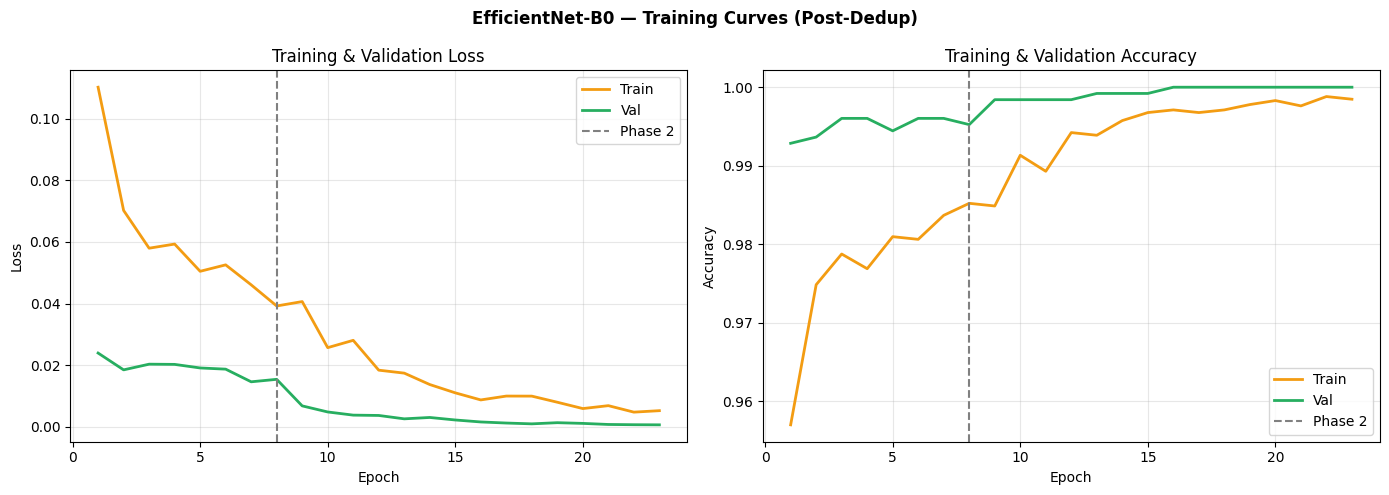

Train-val gap: -0.0015 ✅ Healthy


In [ ]:
p1_end_en = len(en_hist_p1['train_loss']) - 1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EfficientNet-B0 — Training Curves (Post-Dedup)', fontweight='bold')
for ax, (tk, vk), title, ylabel_text in zip(axes,
    [('train_loss','val_loss'),('train_acc','val_acc')],
     ['Training & Validation Loss','Training & Validation Accuracy'],
    ['Loss', 'Accuracy']): # Added this list for y-axis labels
    epochs = range(1, len(en_history[tk]) + 1)
    ax.plot(epochs, en_history[tk], label='Train', lw=2, color='#F39C12')
    ax.plot(epochs, en_history[vk], label='Val',   lw=2, color='#27AE60')
    ax.axvline(p1_end_en + 1, color='gray', ls='--', lw=1.5, label='Phase 2')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel_text); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

gap = en_history['train_acc'][-1] - en_history['val_acc'][-1]
print(f'Train-val gap: {gap:.4f}', '✅ Healthy' if abs(gap) < 0.05 else '⚠️  Check for overfit')

## Cell 17 — EfficientNet-B0 Evaluation

In [ ]:
print('═'*55)
print('EfficientNet-B0 — Test Set Evaluation')
print('═'*55)
en_results = evaluate_model(en_model, en_dl['test'], en_ds['test'])
print(classification_report(en_results['labels'], en_results['preds'],
                             target_names=cfg.CLASS_NAMES))
print(f'Sensitivity : {en_results["sensitivity"]:.4f}')
print(f'Specificity : {en_results["specificity"]:.4f}')
print(f'PPV         : {en_results["ppv"]:.4f}')
print(f'NPV         : {en_results["npv"]:.4f}')
print(f'AUC-ROC     : {en_results["auc"]:.4f}')
print(f'Accuracy    : {en_results["accuracy"]:.4f}')

═══════════════════════════════════════════════════════
EfficientNet-B0 — Test Set Evaluation
═══════════════════════════════════════════════════════


Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

                            precision    recall  f1-score   support

Adenocarcinoma (Malignant)       1.00      1.00      1.00       627
           Normal (Benign)       1.00      1.00      1.00       636

                  accuracy                           1.00      1263
                 macro avg       1.00      1.00      1.00      1263
              weighted avg       1.00      1.00      1.00      1263

Sensitivity : 1.0000
Specificity : 1.0000
PPV         : 1.0000
NPV         : 1.0000
AUC-ROC     : 1.0000
Accuracy    : 1.0000


---
# 📊 HEAD-TO-HEAD COMPARISON

## Cell 18 — Side-by-Side Metrics + Curves

In [ ]:
import pandas as pd

# ── Metrics comparison table ──────────────────────────────────────────────
print('\n' + '═'*58)
print('        HEAD-TO-HEAD COMPARISON — POST-DEDUP RESULTS')
print('═'*58)

metrics = ['accuracy', 'sensitivity', 'specificity', 'ppv', 'npv', 'auc']
labels  = ['Accuracy', 'Sensitivity', 'Specificity', 'PPV', 'NPV', 'AUC-ROC']

comp_data = {}
for lbl, key in zip(labels, metrics):
    rn_val = rn_results[key]
    en_val = en_results[key]
    winner = 'ResNet-18' if rn_val > en_val else ('EfficientNet-B0' if en_val > rn_val else 'Tie')
    comp_data[lbl] = {
        'ResNet-18':       f'{rn_val:.4f}',
        'EfficientNet-B0': f'{en_val:.4f}',
        'Winner':          winner
    }

df_comp = pd.DataFrame(comp_data).T
print(df_comp.to_string())

# Model size comparison
rn_params = sum(p.numel() for p in rn_model.parameters()) / 1e6
en_params = sum(p.numel() for p in en_model.parameters()) / 1e6
print(f'\nModel Parameters:')
print(f'  ResNet-18      : {rn_params:.1f}M')
print(f'  EfficientNet-B0: {en_params:.1f}M')

# Training epochs actually used (early stopping may have reduced these)
rn_epochs = len(rn_history['train_loss'])
en_epochs = len(en_history['train_loss'])
print(f'\nEpochs trained:')
print(f'  ResNet-18      : {rn_epochs}')
print(f'  EfficientNet-B0: {en_epochs}')


══════════════════════════════════════════════════════════
        HEAD-TO-HEAD COMPARISON — POST-DEDUP RESULTS
══════════════════════════════════════════════════════════
            ResNet-18 EfficientNet-B0 Winner
Accuracy       1.0000          1.0000    Tie
Sensitivity    1.0000          1.0000    Tie
Specificity    1.0000          1.0000    Tie
PPV            1.0000          1.0000    Tie
NPV            1.0000          1.0000    Tie
AUC-ROC        1.0000          1.0000    Tie

Model Parameters:
  ResNet-18      : 11.3M
  EfficientNet-B0: 4.3M

Epochs trained:
  ResNet-18      : 22
  EfficientNet-B0: 23


NameError: name 'rn_history' is not defined

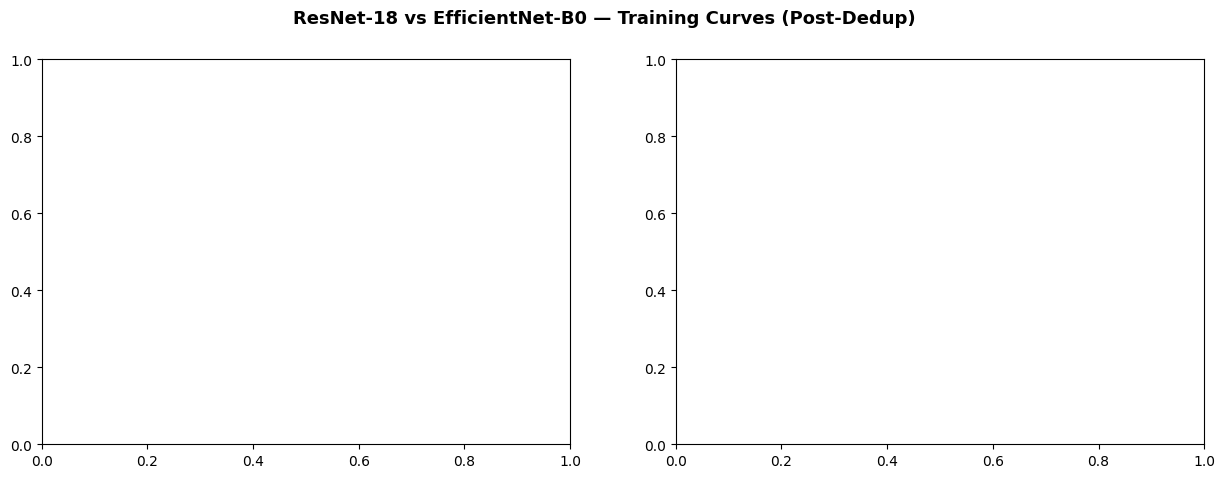

In [ ]:
import matplotlib.pyplot as plt

# ── Overlay training curves ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('ResNet-18 vs EfficientNet-B0 — Training Curves (Post-Dedup)',
             fontweight='bold', fontsize=13)

rn_e = range(1, len(rn_history['train_loss']) + 1)
en_e = range(1, len(en_history['train_loss']) + 1)

for ax, (tk, vk), title, ylabel_text in zip(axes,
    [('train_loss','val_loss'),('train_acc','val_acc')],
     ['Training & Validation Loss','Training & Validation Accuracy'],
    ['Loss', 'Accuracy']): # Added this list for y-axis labels

    ax.plot(rn_e, rn_history[tk], lw=2, color='#3498DB', ls='-',  label='ResNet-18 Train')
    ax.plot(rn_e, rn_history[vk], lw=2, color='#3498DB', ls='--', label='ResNet-18 Val',   alpha=0.7)
    ax.plot(en_e, en_history[tk], lw=2, color='#E67E22', ls='-',  label='EffNet-B0 Train')
    ax.plot(en_e, en_history[vk], lw=2, color='#E67E22', ls='--', label='EffNet-B0 Val',   alpha=0.7)

    ax.axvline(p1_end_rn + 1, color='#3498DB', ls=':', lw=1, alpha=0.5)
    ax.axvline(p1_end_en + 1, color='#E67E22', ls=':', lw=1, alpha=0.5)
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel_text); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/comparison_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: /content/comparison_curves.png')

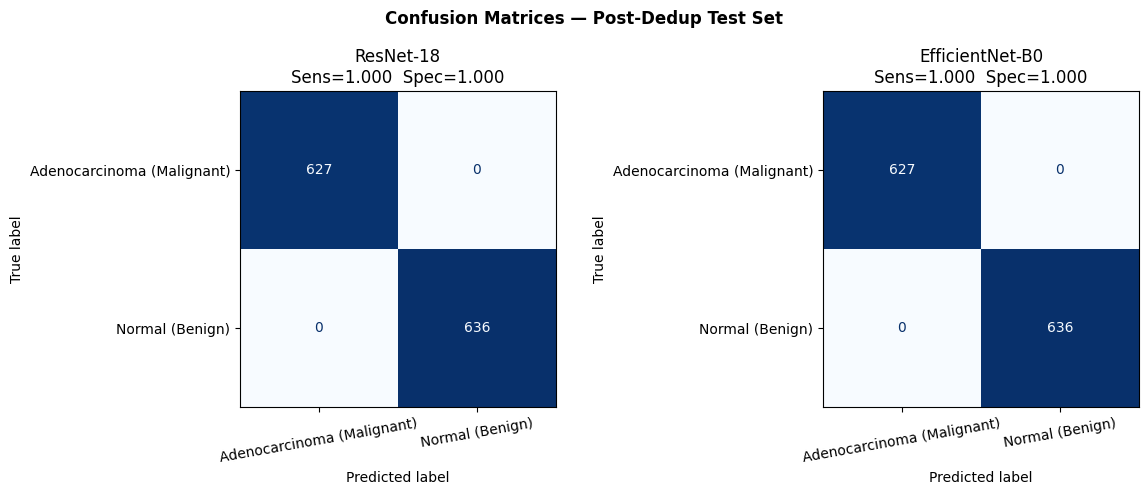

In [ ]:
# ── Side-by-side confusion matrices ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrices — Post-Dedup Test Set', fontweight='bold')

for ax, results, name in zip(axes,
    [rn_results, en_results],
    ['ResNet-18', 'EfficientNet-B0']):
    ConfusionMatrixDisplay(results['cm'], display_labels=cfg.CLASS_NAMES).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(f'{name}\nSens={results["sensitivity"]:.3f}  Spec={results["specificity"]:.3f}')
    ax.tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.savefig('/content/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

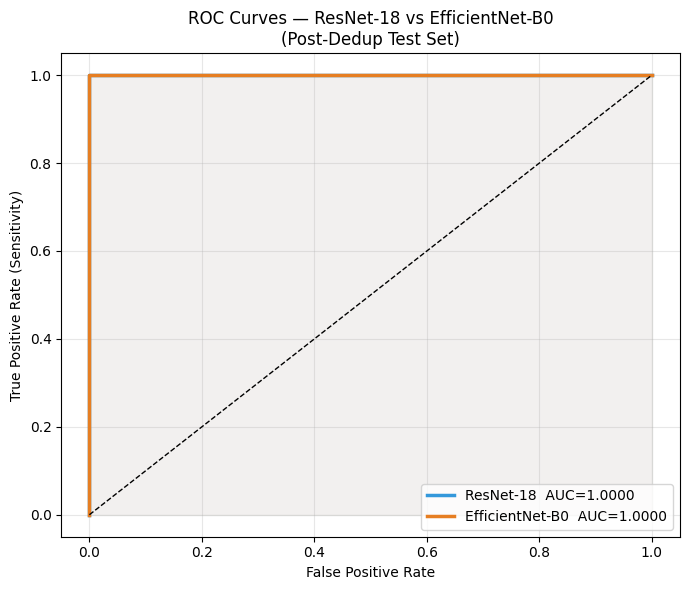

In [ ]:
# ── Overlaid ROC curves ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

for results, name, color in [
    (rn_results, 'ResNet-18',       '#3498DB'),
    (en_results, 'EfficientNet-B0', '#E67E22')
]:
    fpr, tpr, _ = roc_curve(results['binary'], results['mal_prob'])
    # Flip if inverted
    auc_check = roc_auc_score(results['binary'], results['mal_prob'])
    if auc_check < 0.5:
        fpr, tpr = 1 - fpr[::-1], 1 - tpr[::-1]
    ax.plot(fpr, tpr, lw=2.5, color=color,
            label=f'{name}  AUC={results["auc"]:.4f}')
    ax.fill_between(fpr, tpr, alpha=0.06, color=color)

ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('ROC Curves — ResNet-18 vs EfficientNet-B0\n(Post-Dedup Test Set)')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 19 — Save Everything to Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
save_dir = '/content/drive/MyDrive/colon_cancer_comparison'
os.makedirs(save_dir, exist_ok=True)

# Model weights
shutil.copy('/content/rn_best.pth', f'{save_dir}/resnet18_best.pth')
shutil.copy('/content/en_best.pth', f'{save_dir}/efficientnet_b0_best.pth')

# Plots
shutil.copy('/content/comparison_curves.png',  f'{save_dir}/comparison_curves.png')
shutil.copy('/content/confusion_matrices.png', f'{save_dir}/confusion_matrices.png')
shutil.copy('/content/roc_comparison.png',     f'{save_dir}/roc_comparison.png')

# Results CSV
metrics_rows = []
for name, results in [('ResNet-18', rn_results), ('EfficientNet-B0', en_results)]:
    metrics_rows.append({
        'Model':       name,
        'Accuracy':    round(results['accuracy'],    4),
        'Sensitivity': round(results['sensitivity'], 4),
        'Specificity': round(results['specificity'], 4),
        'PPV':         round(results['ppv'],         4),
        'NPV':         round(results['npv'],         4),
        'AUC-ROC':     round(results['auc'],         4),
        'Params_M':    round(sum(p.numel() for p in
                           (rn_model if name=='ResNet-18' else en_model).parameters()) / 1e6, 1),
        'Epochs':      len(rn_history['train_loss'] if name=='ResNet-18' else en_history['train_loss'])
    })

df_results = pd.DataFrame(metrics_rows).set_index('Model')
df_results.to_csv(f'{save_dir}/comparison_results.csv')
print('✅ Saved to Google Drive:')
print(f'   {save_dir}')
print(df_results.to_string())

## Build MobileNetV2

In [ ]:
# ── All imports and shared utilities already loaded from Cell 7 ───────────
# ── cfg, make_dataloaders, train_model, evaluate_model all available ──────

def build_mobilenetv2(num_classes, freeze_backbone=True):
    """
    MobileNetV2 classifier head:
      - model.classifier is a Sequential(Dropout, Linear(1280, 1000))
      - We replace the entire classifier block with our regularised head
      - Backbone freeze: parameters NOT in 'classifier' are frozen

    MobileNetV2 feature extractor ends with a 1280-dim vector after
    AdaptiveAvgPool2d — same dimensionality as EfficientNet-B0, but
    produced by depthwise separable convolutions instead of MBConv blocks.
    """
    model = models.mobilenet_v2(weights='IMAGENET1K_V1')
    in_features = model.classifier[1].in_features  # 1280

    model.classifier = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.BatchNorm1d(256),
        nn.Dropout(p=0.4),
        nn.Linear(256, num_classes),
    )

    if freeze_backbone:
        for name, p in model.named_parameters():
            if 'classifier' not in name:
                p.requires_grad = False

    return model


# ── MobileNetV2 config (slightly smaller batch safe on T4) ────────────────
MN_BATCH_SIZE    = 64
MN_PHASE1_EPOCHS = 8
MN_PHASE1_LR     = 1e-3
MN_PHASE2_EPOCHS = 15
MN_PHASE2_LR     = 1e-5   # conservative — depthwise conv layers sensitive
                           # to large updates once unfrozen

mn_ds, mn_dl   = make_dataloaders(MN_BATCH_SIZE)
mn_model       = build_mobilenetv2(cfg.NUM_CLASSES, freeze_backbone=True).to(cfg.DEVICE)
mn_criterion   = make_criterion(mn_ds['train'])

trainable = sum(p.numel() for p in mn_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in mn_model.parameters())
print(f'MobileNetV2       |  Trainable: {trainable:,} / {total:,} params')
print(f'Train set         : {len(mn_ds["train"])} images (post-dedup)')
print(f'Test set          : {len(mn_ds["test"])}  images (post-dedup)')
print()
print('Architecture note:')
print('  Backbone : Inverted residual blocks (depthwise separable conv)')
print('  Head attr: model.classifier')
print('  Feature  : 1280-dim after adaptive avg pool')
print('  Freeze   : all layers except classifier frozen in Phase 1')

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 153MB/s]

MobileNetV2       |  Trainable: 328,962 / 2,552,834 params
Train set         : 5880 images (post-dedup)
Test set          : 1263  images (post-dedup)

Architecture note:
  Backbone : Inverted residual blocks (depthwise separable conv)
  Head attr: model.classifier
  Feature  : 1280-dim after adaptive avg pool
  Freeze   : all layers except classifier frozen in Phase 1


## Cell 21 — MobileNetV2 Phase 1: Train Head Only

In [ ]:
print('MobileNetV2 — Phase 1: head only (backbone frozen)')
print(f'Epochs: {MN_PHASE1_EPOCHS}  |  LR: {MN_PHASE1_LR}  |  Batch: {MN_BATCH_SIZE}')
print('─' * 50)

mn_opt_p1 = optim.AdamW(
    filter(lambda p: p.requires_grad, mn_model.parameters()),
    lr=MN_PHASE1_LR, weight_decay=1e-4
)
mn_sch_p1 = optim.lr_scheduler.ReduceLROnPlateau(
    mn_opt_p1, mode='min', factor=0.5, patience=2
)
mn_model, mn_hist_p1 = train_model(
    mn_model, mn_criterion, mn_opt_p1, mn_sch_p1,
    mn_dl, MN_PHASE1_EPOCHS, '/content/mn_best.pth', 'MN Phase1'
)

MobileNetV2 — Phase 1: head only (backbone frozen)
Epochs: 8  |  LR: 0.001  |  Batch: 64
──────────────────────────────────────────────────
[MN Phase1] Epoch 1/8


  train:   0%|          | 0/92 [00:00<?, ?it/s]

    train → loss: 0.0526  acc: 0.9794


  val:   0%|          | 0/20 [00:00<?, ?it/s]

    val   → loss: 0.0318  acc: 0.9889
    ✅ Best saved (val_loss=0.0318)
[MN Phase1] Epoch 2/8


...

    val   → loss: 0.0182  acc: 0.9944
    ⏳ No improvement (1/5)
[MN Phase1] Epoch 8/8


  train:   0%|          | 0/92 [00:00<?, ?it/s]

    train → loss: 0.0389  acc: 0.9854


  val:   0%|          | 0/20 [00:00<?, ?it/s]

    val   → loss: 0.0178  acc: 0.9952
    ⏳ No improvement (2/5)


## Cell 22 — MobileNetV2 Phase 2: Full Fine-Tuning

In [ ]:
print('MobileNetV2 — Phase 2: all layers unfrozen')
print(f'Epochs: {MN_PHASE2_EPOCHS}  |  LR: {MN_PHASE2_LR}  |  Batch: {MN_BATCH_SIZE}')
print('─' * 50)

for p in mn_model.parameters():
    p.requires_grad = True

mn_opt_p2 = optim.AdamW(
    mn_model.parameters(), lr=MN_PHASE2_LR, weight_decay=1e-4
)
mn_sch_p2 = optim.lr_scheduler.CosineAnnealingLR(
    mn_opt_p2, T_max=MN_PHASE2_EPOCHS, eta_min=1e-7
)
mn_model, mn_hist_p2 = train_model(
    mn_model, mn_criterion, mn_opt_p2, mn_sch_p2,
    mn_dl, MN_PHASE2_EPOCHS, '/content/mn_best.pth', 'MN Phase2'
)

mn_history = {k: mn_hist_p1[k] + mn_hist_p2[k] for k in mn_hist_p1}
print('\nMobileNetV2 training complete ✅')

MobileNetV2 — Phase 2: all layers unfrozen
Epochs: 15  |  LR: 1e-05  |  Batch: 64
──────────────────────────────────────────────────
[MN Phase2] Epoch 1/15


  train:   0%|          | 0/92 [00:00<?, ?it/s]

    train → loss: 0.0279  acc: 0.9898


  val:   0%|          | 0/20 [00:00<?, ?it/s]

    val   → loss: 0.0082  acc: 0.9976
    ✅ Best saved (val_loss=0.0082)
[MN Phase2] Epoch 2/15


...

    val   → loss: 0.0002  acc: 1.0000
    ✅ Best saved (val_loss=0.0002)
[MN Phase2] Epoch 15/15


  train:   0%|          | 0/92 [00:00<?, ?it/s]

    train → loss: 0.0017  acc: 0.9998


  val:   0%|          | 0/20 [00:00<?, ?it/s]

    val   → loss: 0.0004  acc: 1.0000
    ⏳ No improvement (1/5)

MobileNetV2 training complete ✅


## Cell 23 — MobileNetV2 Training Curves

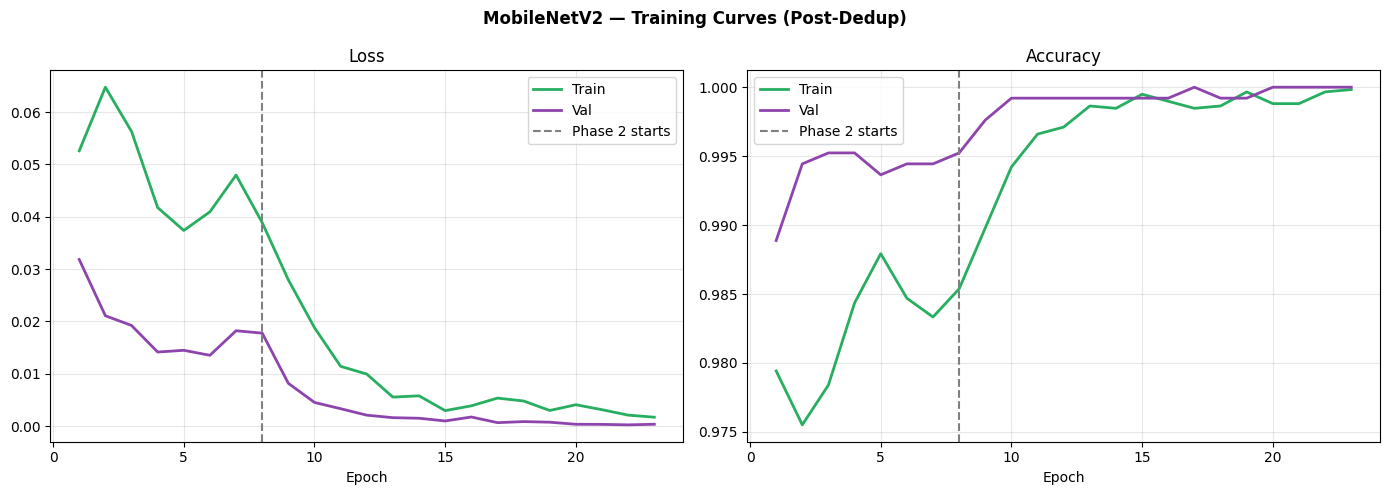

Final train acc : 0.9998
Final val acc   : 1.0000
Train-val gap   : -0.0002 ✅ Healthy


In [ ]:
import matplotlib.pyplot as plt

p1_end_mn = len(mn_hist_p1['train_loss']) - 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MobileNetV2 — Training Curves (Post-Dedup)', fontweight='bold')

for ax, (tk, vk), title in zip(
    axes,
    [('train_loss', 'val_loss'), ('train_acc', 'val_acc')],
    ['Training & Validation Loss', 'Training & Validation Accuracy']
):
    epochs = range(1, len(mn_history[tk]) + 1)
    ax.plot(epochs, mn_history[tk], label='Train', lw=2, color='#27AE60')
    ax.plot(epochs, mn_history[vk], label='Val',   lw=2, color='#8E44AD')
    ax.axvline(p1_end_mn + 1, color='gray', ls='--', lw=1.5, label='Phase 2 starts')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel()
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/mobilenetv2_curves.png', dpi=150, bbox_inches='tight')
plt.show()

gap = mn_history['train_acc'][-1] - mn_history['val_acc'][-1]
print(f'Final train acc : {mn_history["train_acc"][-1]:.4f}')
print(f'Final val acc   : {mn_history["val_acc"][-1]:.4f}')
print(f'Train-val gap   : {gap:.4f}', '✅ Healthy' if abs(gap) < 0.05 else '⚠️  Check for overfit')

## Cell 24 — MobileNetV2 Evaluation

In [ ]:
from sklearn.metrics import classification_report

print('═' * 55)
print('MobileNetV2 — Test Set Evaluation')
print('═' * 55)

mn_results = evaluate_model(mn_model, mn_dl['test'], mn_ds['test'])

print(classification_report(
    mn_results['labels'], mn_results['preds'],
    target_names=cfg.CLASS_NAMES
))
print(f'Sensitivity : {mn_results["sensitivity"]:.4f}')
print(f'Specificity : {mn_results["specificity"]:.4f}')
print(f'PPV         : {mn_results["ppv"]:.4f}')
print(f'NPV         : {mn_results["npv"]:.4f}')
print(f'AUC-ROC     : {mn_results["auc"]:.4f}')
print(f'Accuracy    : {mn_results["accuracy"]:.4f}')

---
# 📊 THREE-MODEL COMPARISON: ResNet-18 vs EfficientNet-B0 vs MobileNetV2

## Cell 25 — Three-Model Metrics Table

In [ ]:
import pandas as pd

print('\n' + '═' * 65)
print('   THREE-MODEL COMPARISON — POST-DEDUP TEST SET RESULTS')
print('═' * 65)

metric_keys   = ['accuracy', 'sensitivity', 'specificity', 'ppv', 'npv', 'auc']
metric_labels = ['Accuracy', 'Sensitivity', 'Specificity', 'PPV', 'NPV', 'AUC-ROC']

models_info = [
    ('ResNet-18',        rn_results,  rn_model,  rn_history),
    ('EfficientNet-B0',  en_results,  en_model,  en_history),
    ('MobileNetV2',      mn_results,  mn_model,  mn_history),
]

rows = []
for name, results, model, history in models_info:
    params = sum(p.numel() for p in model.parameters()) / 1e6
    epochs = len(history['train_loss'])
    row = {'Model': name, 'Params (M)': f'{params:.1f}', 'Epochs': epochs}
    for lbl, key in zip(metric_labels, metric_keys):
        row[lbl] = round(results[key], 4)
    rows.append(row)

df_all = pd.DataFrame(rows).set_index('Model')
print(df_all.to_string())

# ── Best model per metric ─────────────────────────────────────────────────
print('\n── Best model per metric ──────────────────────────────────')
for lbl, key in zip(metric_labels, metric_keys):
    best_name = max(models_info, key=lambda x: x[1][key])[0]
    best_val  = max(r[key] for _, r, _, _ in models_info)
    print(f'  {lbl:12s}: {best_name} ({best_val:.4f})')

# ── Efficiency metric: accuracy per million parameters ───────────────────
print('\n── Efficiency (Accuracy / Params) ─────────────────────────')
for name, results, model, _ in models_info:
    params = sum(p.numel() for p in model.parameters()) / 1e6
    eff    = results['accuracy'] / params
    print(f'  {name:18s}: {eff:.4f}  (acc={results["accuracy"]:.4f} / {params:.1f}M params)')

## Cell 26 — Overlaid Training Curves (All Three Models)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'ResNet-18 vs EfficientNet-B0 vs MobileNetV2\nTraining Curves (Post-Dedup)',
    fontweight='bold', fontsize=13
)

plot_models = [
    ('ResNet-18',       rn_history, p1_end_rn, '#3498DB'),
    ('EfficientNet-B0', en_history, p1_end_en, '#E67E22'),
    ('MobileNetV2',     mn_history, p1_end_mn, '#27AE60'),
]

for ax, (tk, vk), title in zip(
    axes,
    [('train_loss', 'val_loss'), ('train_acc', 'val_acc')],
    ['Loss', 'Accuracy']
):
    for name, history, p1_end, color in plot_models:
        epochs = range(1, len(history[tk]) + 1)
        ax.plot(epochs, history[tk], lw=2,   color=color, ls='-',
                label=f'{name} Train')
        ax.plot(epochs, history[vk], lw=1.5, color=color, ls='--',
                label=f'{name} Val', alpha=0.75)
        ax.axvline(p1_end + 1, color=color, ls=':', lw=1, alpha=0.4)

    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=7, ncol=2)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/three_model_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: /content/three_model_curves.png')

## Cell 27 — Three Confusion Matrices Side by Side

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Confusion Matrices — Post-Dedup Test Set', fontweight='bold', fontsize=13)

for ax, (name, results, _, _) in zip(axes, models_info):
    ConfusionMatrixDisplay(
        results['cm'], display_labels=cfg.CLASS_NAMES
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(
        f'{name}\n'
        f'Sens={results["sensitivity"]:.3f}  '
        f'Spec={results["specificity"]:.3f}  '
        f'AUC={results["auc"]:.3f}',
        fontsize=10
    )
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('/content/three_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 28 — Three ROC Curves Overlaid

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(7, 6))

colors = ['#3498DB', '#E67E22', '#27AE60']
for (name, results, _, _), color in zip(models_info, colors):
    fpr, tpr, _ = roc_curve(results['binary'], results['mal_prob'])
    # Safety flip for inverted AUC
    raw_auc = roc_auc_score(results['binary'], results['mal_prob'])
    if raw_auc < 0.5:
        fpr = 1 - fpr[::-1]
        tpr = 1 - tpr[::-1]
    ax.plot(fpr, tpr, lw=2.5, color=color,
            label=f'{name}  AUC = {results["auc"]:.4f}')
    ax.fill_between(fpr, tpr, alpha=0.05, color=color)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
ax.set_ylabel('True Positive Rate (Sensitivity)',      fontsize=11)
ax.set_title(
    'ROC Curves — ResNet-18 vs EfficientNet-B0 vs MobileNetV2\n'
    '(Post-Dedup Test Set)',
    fontsize=11
)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/three_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: /content/three_roc_curves.png')